# Quantum Gates — Teaching Notebook

This notebook develops quantum gates from **single-qubit rotations** to **controlled and multi-qubit gates**, with circuit diagrams, statevectors, Bloch-sphere visualisation, and measurement.

## Learning goals
By the end, students should be able to:
- distinguish bit flips, phase flips, and rotations;
- explain the action of X, Y, Z, S, T, Rx, Ry, and Rz;
- interpret controlled gates such as CNOT, CZ, and controlled-Rθ;
- explain SWAP, Toffoli (CCX), and Fredkin (CSWAP);
- prepare and measure a Bell state;
- understand when a Bloch sphere is useful and when entanglement prevents a single pure-state Bloch-vector description.


## 0. Installation

Run this cell once if Qiskit is not installed. Restart the kernel if your environment requires it.


In [ ]:
%pip install -q qiskit qiskit-aer matplotlib


## 1. Imports and helper functions

We use:
- `QuantumCircuit` to build circuits;
- `Statevector` for exact state evolution;
- `plot_bloch_multivector` for qubit Bloch vectors;
- `plot_histogram` for measurement counts;
- Aer for shot-based measurement simulation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit.visualization import (
    plot_bloch_multivector,
    plot_histogram,
    array_to_latex
)
from qiskit_aer import AerSimulator

simulator = AerSimulator()

def show_state(qc, title=None):
    """Display circuit, statevector, and Bloch representation before measurement."""
    if title:
        print(title)
    display(qc.draw("mpl"))
    state = Statevector.from_instruction(qc)
    display(array_to_latex(state.data, prefix="|ψ⟩ = "))
    display(plot_bloch_multivector(state))
    return state

def measure_counts(qc, shots=1024):
    """Measure all qubits on a copy of qc and return counts."""
    measured = qc.copy()
    measured.measure_all()
    display(measured.draw("mpl"))
    compiled = transpile(measured, simulator)
    result = simulator.run(compiled, shots=shots).result()
    counts = result.get_counts()
    display(plot_histogram(counts))
    print(counts)
    return counts


# Part I — The Bloch sphere

A pure single-qubit state can be written as

$$
|\psi\rangle =
\cos\left(\frac{\theta}{2}\right)|0\rangle+
e^{i\phi}\sin\left(\frac{\theta}{2}\right)|1\rangle.
$$

- North pole: $|0\rangle$
- South pole: $|1\rangle$
- $+x$: $|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$
- $-x$: $|-\rangle=(|0\rangle-|1\rangle)/\sqrt2$
- $+y$: $(|0\rangle+i|1\rangle)/\sqrt2$
- $-y$: $(|0\rangle-i|1\rangle)/\sqrt2$

The Bloch sphere shows **relative amplitude and relative phase**, not global phase.


|0>


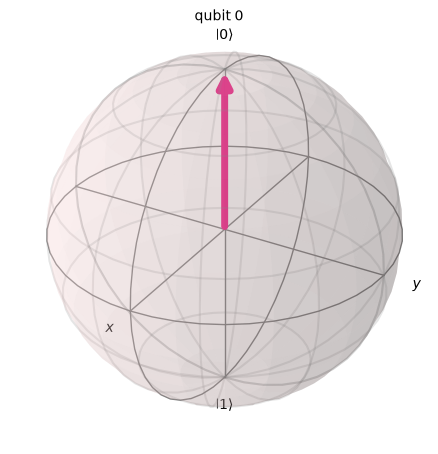

|1>


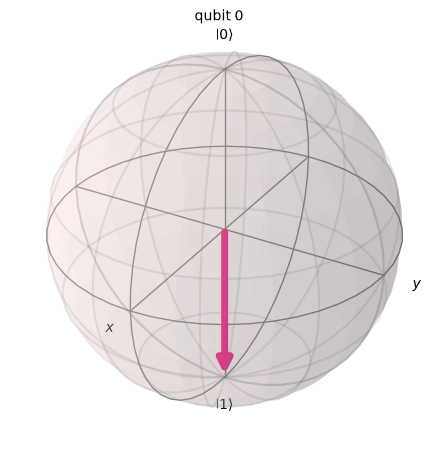

|+>


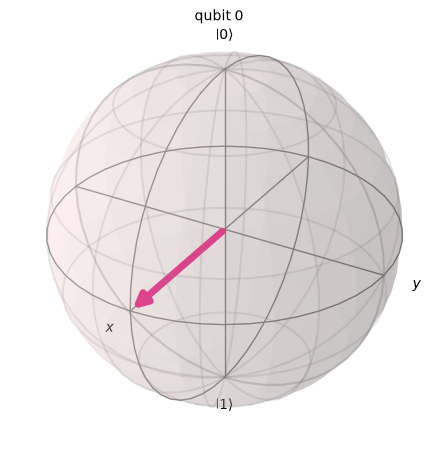

|->


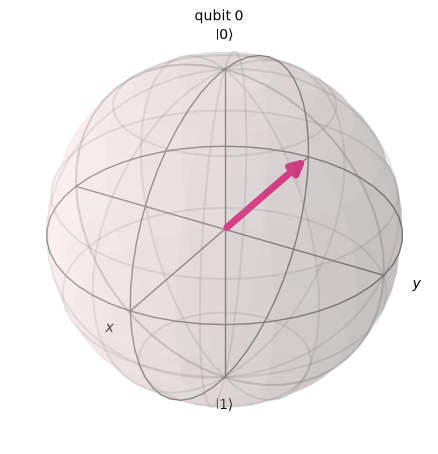

|+i>


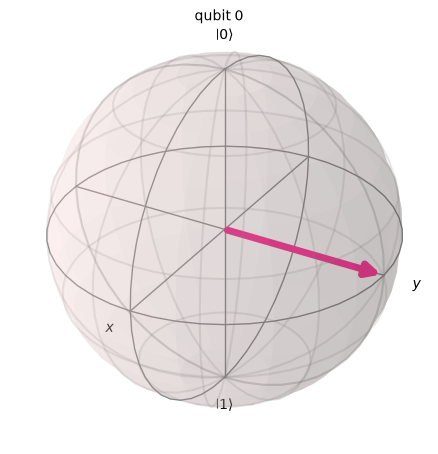

|-i>


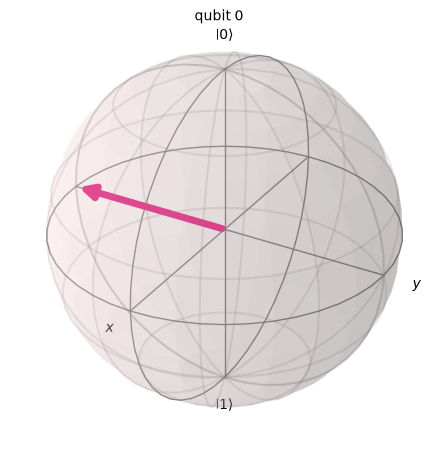

In [2]:
states = {
    "|0>": Statevector([1, 0]),
    "|1>": Statevector([0, 1]),
    "|+>": Statevector([1, 1]) / np.sqrt(2),
    "|->": Statevector([1, -1]) / np.sqrt(2),
    "|+i>": Statevector([1, 1j]) / np.sqrt(2),
    "|-i>": Statevector([1, -1j]) / np.sqrt(2),
}

for name, state in states.items():
    print(name)
    display(plot_bloch_multivector(state))


# Part II — Pauli gates

## 2. Pauli-X: bit flip

$$
X=\begin{bmatrix}0&1\\1&0\end{bmatrix}
$$

It exchanges the computational basis states:

$$
X|0\rangle=|1\rangle,\qquad X|1\rangle=|0\rangle.
$$

Geometrically, X is a rotation by $\pi$ around the **x-axis** of the Bloch sphere.


X applied to |0>


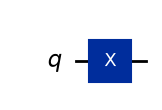

<IPython.core.display.Latex object>

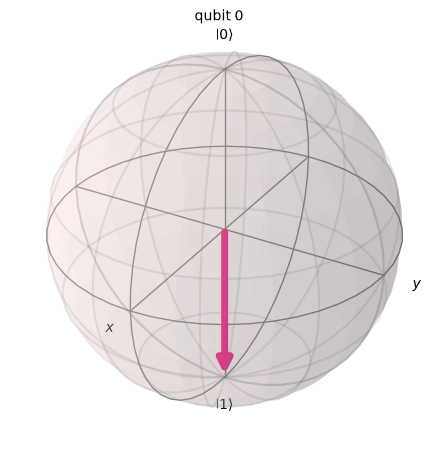

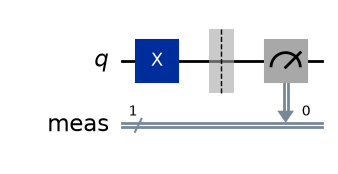

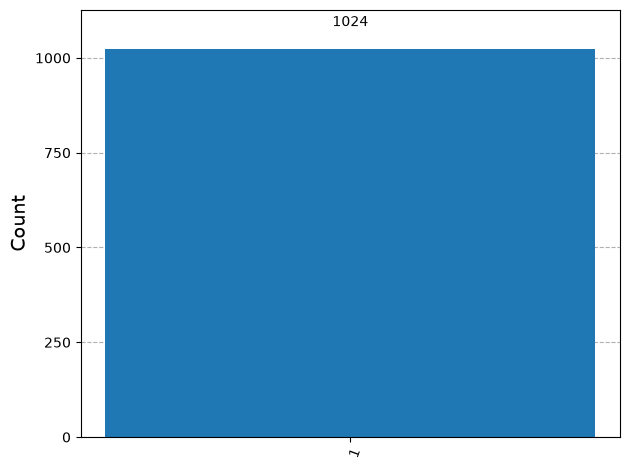

{'1': 1024}


{'1': 1024}

In [3]:
qc = QuantumCircuit(1)
qc.x(0)
show_state(qc, "X applied to |0>")
measure_counts(qc)


## 3. Pauli-Y: bit flip + phase change

$$
Y=\begin{bmatrix}0&-i\\i&0\end{bmatrix}
$$

$$
Y|0\rangle=i|1\rangle,\qquad
Y|1\rangle=-i|0\rangle.
$$

For a computational-basis measurement, the global factor $i$ does not change the probability.  
Geometrically, Y is a $\pi$ rotation around the **y-axis**.


Y applied to |0>


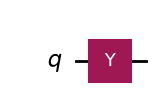

<IPython.core.display.Latex object>

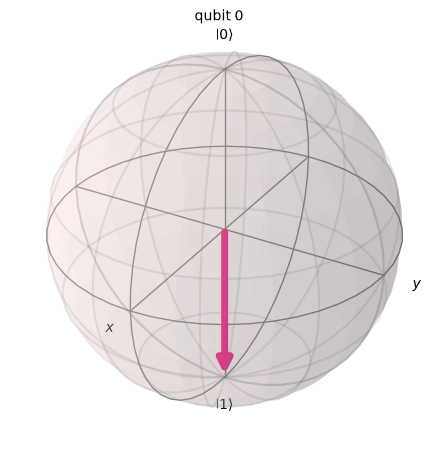

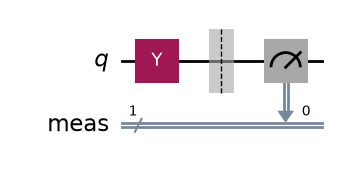

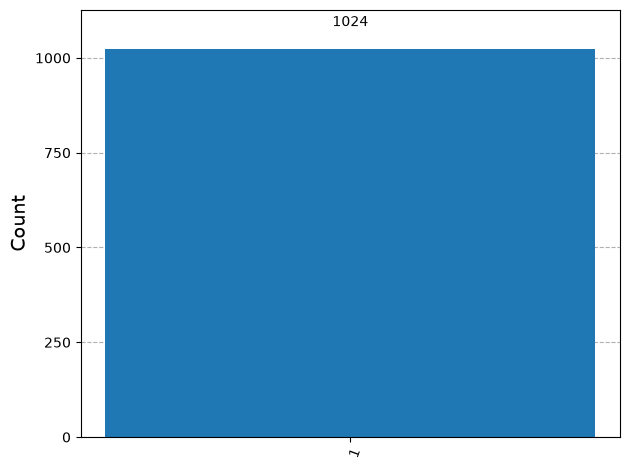

{'1': 1024}


{'1': 1024}

In [4]:
qc = QuantumCircuit(1)
qc.y(0)
show_state(qc, "Y applied to |0>")
measure_counts(qc)


## 4. Pauli-Z: phase flip

$$
Z=\begin{bmatrix}1&0\\0&-1\end{bmatrix}
$$

$$
Z|0\rangle=|0\rangle,\qquad Z|1\rangle=-|1\rangle.
$$

Z does **not** change the computational-basis probabilities immediately. It changes relative phase.

A useful demonstration is

$$
|+\rangle \xrightarrow{Z}|-\rangle.
$$

Geometrically, Z is a $\pi$ rotation around the **z-axis**.


Z applied to |+>


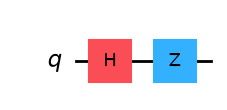

<IPython.core.display.Latex object>

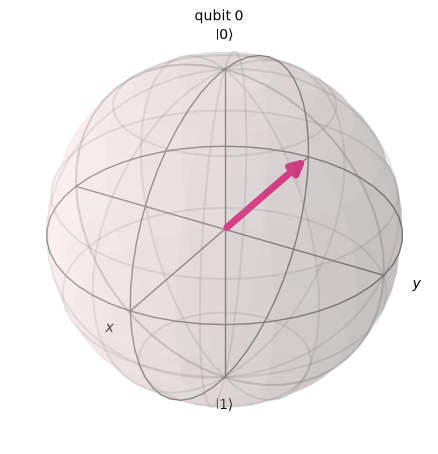

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


In [5]:
qc = QuantumCircuit(1)
qc.h(0)      # |+>
qc.z(0)      # |->
show_state(qc, "Z applied to |+>")


# Part III — Rotation gates

The rotation gates allow continuous rotations rather than only the fixed $\pi$ rotations of Pauli gates.

$$
R_x(\theta)=e^{-i\theta X/2},\quad
R_y(\theta)=e^{-i\theta Y/2},\quad
R_z(\theta)=e^{-i\theta Z/2}.
$$

These gates are important in variational quantum circuits and quantum machine learning.


## 5. $R_x(\theta)$

Rotation around the Bloch sphere's x-axis.


Rx(pi/2) applied to |0>


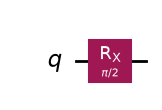

<IPython.core.display.Latex object>

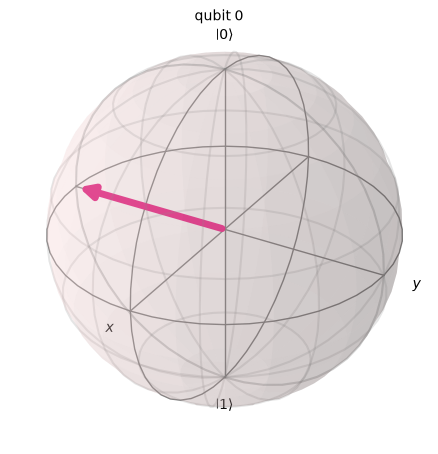

Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


In [6]:
theta = np.pi / 2

qc = QuantumCircuit(1)
qc.rx(theta, 0)
show_state(qc, "Rx(pi/2) applied to |0>")


## 6. $R_y(\theta)$

Rotation around the y-axis.

Starting from $|0\rangle$, $R_y$ directly changes the probabilities of measuring 0 and 1.


Ry(pi/2) applied to |0>


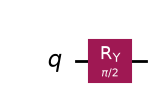

<IPython.core.display.Latex object>

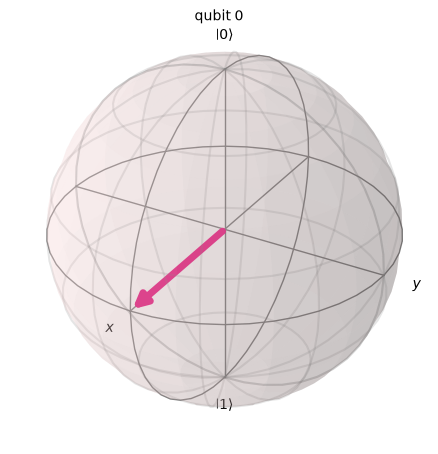

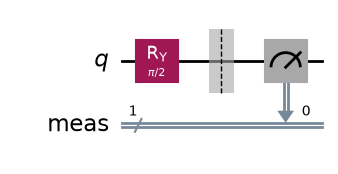

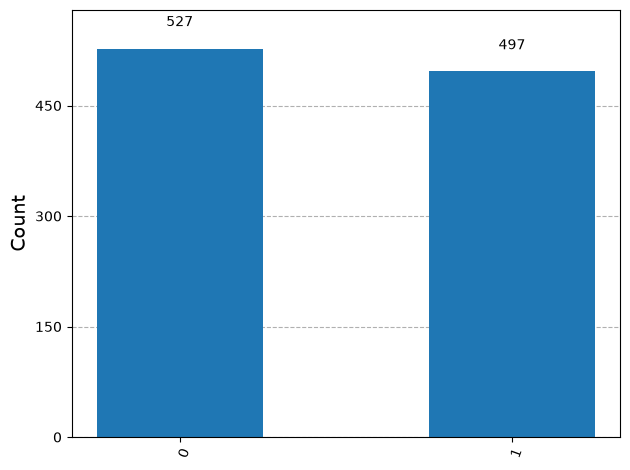

{'1': 497, '0': 527}


{'1': 497, '0': 527}

In [7]:
theta = np.pi / 2

qc = QuantumCircuit(1)
qc.ry(theta, 0)
show_state(qc, "Ry(pi/2) applied to |0>")
measure_counts(qc)


## 7. $R_z(\theta)$

Rotation around the z-axis. If the qubit begins exactly at $|0\rangle$, its Bloch vector lies on the rotation axis, so the change is not visually informative.

We therefore prepare $|+\rangle$ first.


Rz(pi/2) applied to |+>


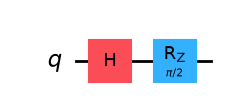

<IPython.core.display.Latex object>

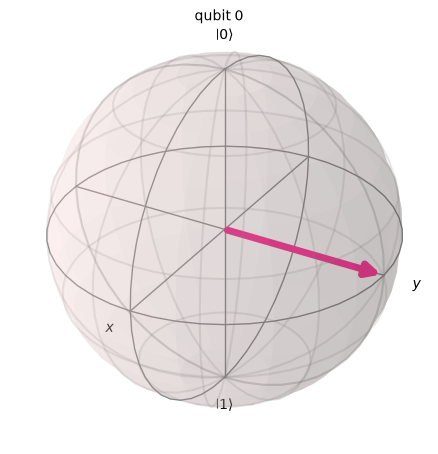

Statevector([0.5-0.5j, 0.5+0.5j],
            dims=(2,))


In [8]:
theta = np.pi / 2

qc = QuantumCircuit(1)
qc.h(0)
qc.rz(theta, 0)
show_state(qc, "Rz(pi/2) applied to |+>")


## Teaching comparison: Pauli gates and rotations

Up to physically irrelevant global phase,

$$
X \sim R_x(\pi),\qquad
Y \sim R_y(\pi),\qquad
Z \sim R_z(\pi).
$$

**Exercise:** change `theta` to $\pi/4,\pi/2,\pi,2\pi$. Predict the Bloch-vector position before running each circuit.


# Part IV — Phase gates S and T

## 8. S gate

$$
S=
\begin{bmatrix}
1&0\\
0&i
\end{bmatrix}.
$$

S adds a phase of $\pi/2$ to the $|1\rangle$ component.

$$
S = P(\pi/2), \qquad S^2=Z.
$$

Prepare $|+\rangle$ so that the relative phase is visible.


In [ ]:
qc = QuantumCircuit(1)
qc.h(0)
qc.s(0)
show_state(qc, "S applied to |+>")


## 9. T gate

$$
T=
\begin{bmatrix}
1&0\\
0&e^{i\pi/4}
\end{bmatrix}.
$$

T adds a $\pi/4$ relative phase.

$$
T=P(\pi/4),\qquad T^2=S,\qquad T^4=Z.
$$

The T gate is especially important in fault-tolerant universal quantum computation.


T applied to |+>


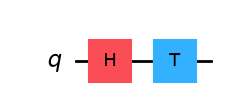

<IPython.core.display.Latex object>

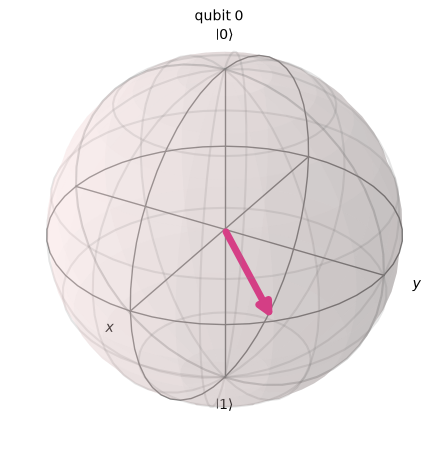

Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


In [9]:
qc = QuantumCircuit(1)
qc.h(0)
qc.t(0)
show_state(qc, "T applied to |+>")


# Part V — Controlled gates

A controlled gate applies an operation to a **target** only when its **control** satisfies the control condition.

This introduces conditional quantum dynamics and is essential for entanglement.


## 10. CNOT / CX

CNOT flips the target when the control is $|1\rangle$.

Basis-state action:

$$
|00\rangle\to|00\rangle,\quad
|01\rangle\to|01\rangle,\quad
|10\rangle\to|11\rangle,\quad
|11\rangle\to|10\rangle
$$

when the first ket bit is interpreted as the control in the conceptual ordering.

The most important teaching use of CNOT is creating entanglement.


CNOT with control qubit prepared as |1>


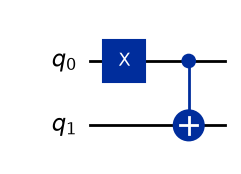

<IPython.core.display.Latex object>

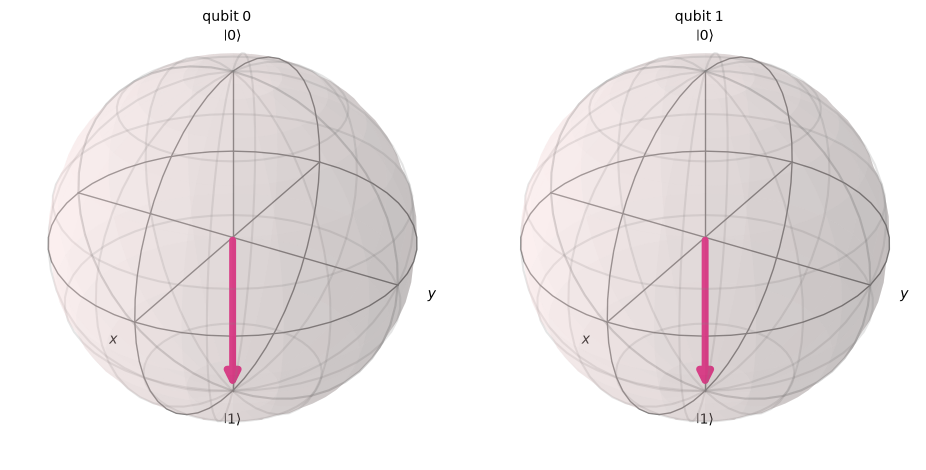

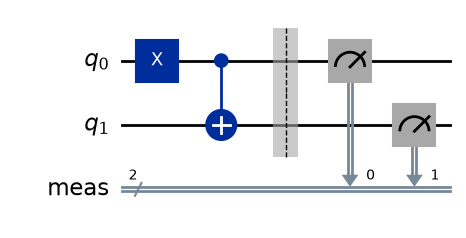

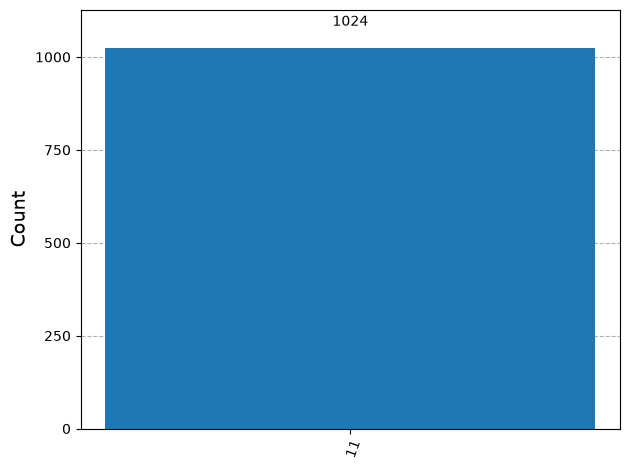

{'11': 1024}


{'11': 1024}

In [10]:
qc = QuantumCircuit(2)
qc.x(0)       # control = 1
qc.cx(0, 1)
show_state(qc, "CNOT with control qubit prepared as |1>")
measure_counts(qc)


## 11. Controlled-Z (CZ)

CZ introduces a minus sign only on $|11\rangle$:

$$
CZ=\operatorname{diag}(1,1,1,-1).
$$

Unlike CNOT, it does not perform a visible computational-basis bit flip. Its effect is on phase.


CZ applied to |++>


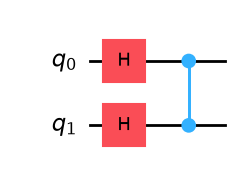

<IPython.core.display.Latex object>

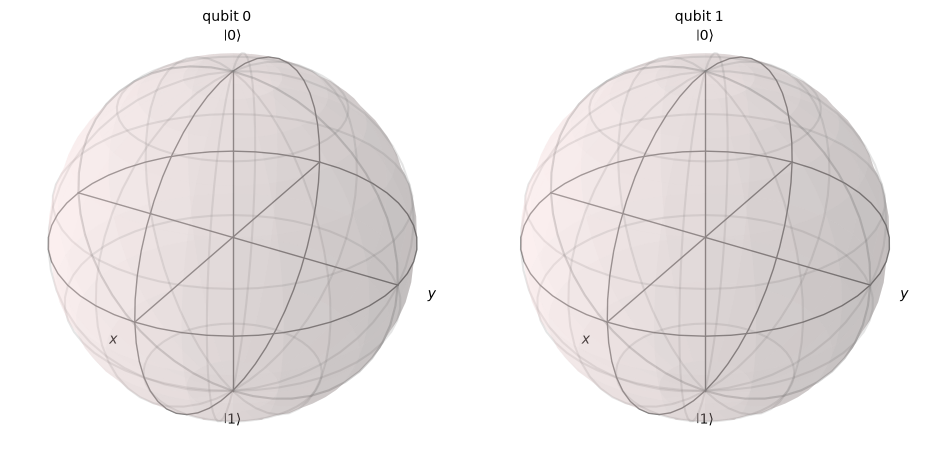

Statevector([ 0.5+0.j,  0.5+0.j,  0.5+0.j, -0.5+0.j],
            dims=(2, 2))


In [11]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.cz(0, 1)
show_state(qc, "CZ applied to |++>")


## 12. Controlled rotation $CR_\theta$

A controlled rotation performs a rotation on the target only when the control is active.

Qiskit provides controlled rotations around each axis:
- `crx(theta, control, target)`
- `cry(theta, control, target)`
- `crz(theta, control, target)`

Below we demonstrate controlled-$R_y(\theta)$.


Controlled-Ry(pi/2)


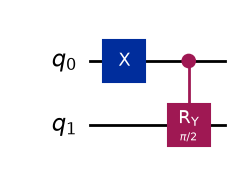

<IPython.core.display.Latex object>

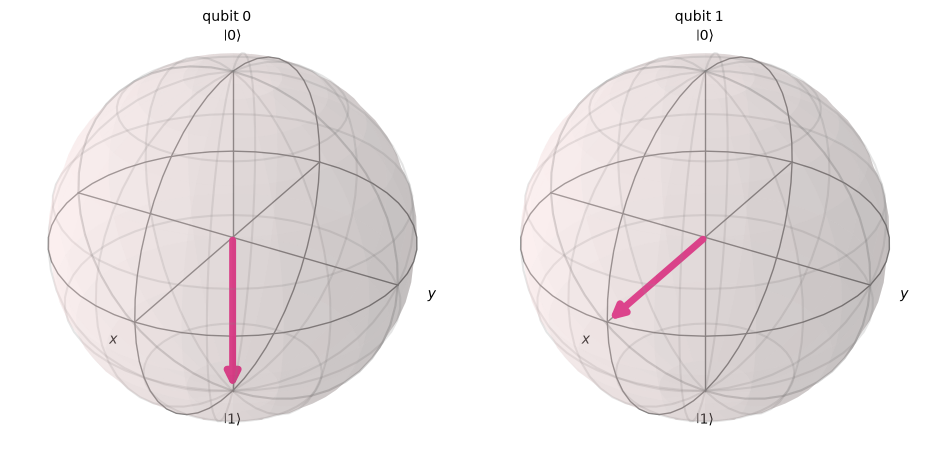

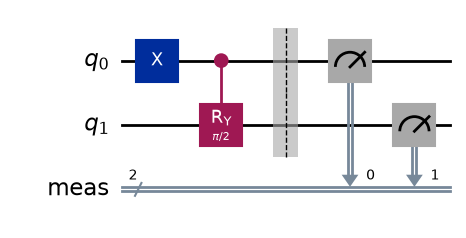

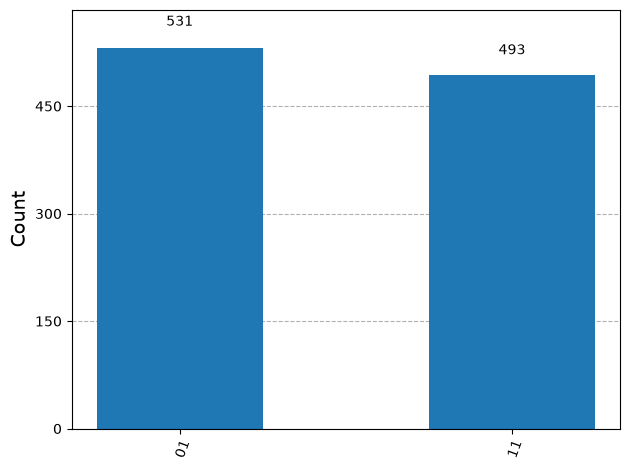

{'11': 493, '01': 531}


{'11': 493, '01': 531}

In [12]:
theta = np.pi / 2

qc = QuantumCircuit(2)
qc.x(0)             # activate control
qc.cry(theta, 0, 1)
show_state(qc, "Controlled-Ry(pi/2)")
measure_counts(qc)


### Controlled phase rotation

If by controlled-$R_\theta$ we mean a controlled phase $P(\theta)$, Qiskit uses `cp(theta, control, target)`.


Controlled phase P(pi/3)


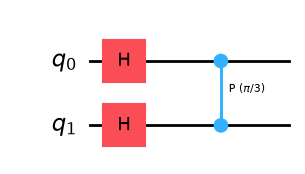

<IPython.core.display.Latex object>

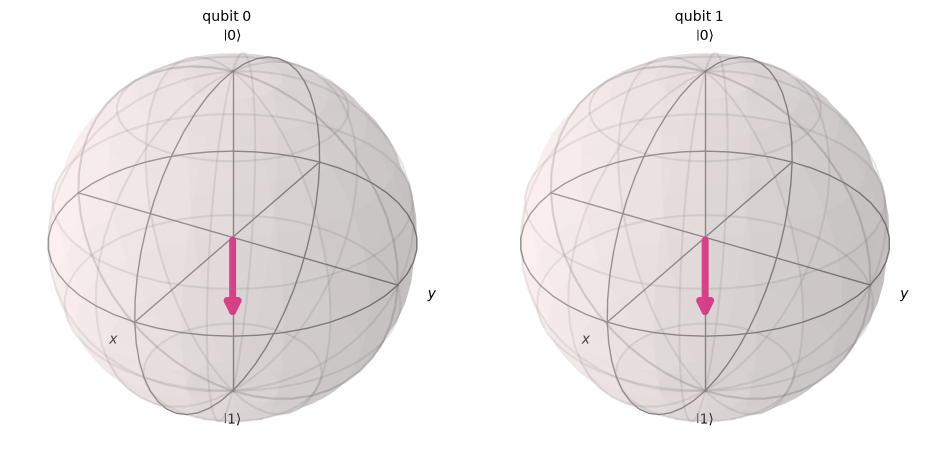

Statevector([0.5 +0.j       , 0.5 +0.j       , 0.5 +0.j       ,
             0.25+0.4330127j],
            dims=(2, 2))


In [13]:
theta = np.pi / 3

qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
qc.cp(theta, 0, 1)
show_state(qc, "Controlled phase P(pi/3)")


# Part VI — Qubit permutation and reversible multi-qubit gates

## 13. SWAP

SWAP exchanges the states of two qubits:

$$
|a,b\rangle\rightarrow|b,a\rangle.
$$

It is useful when hardware connectivity requires moving quantum information between qubits.


SWAP


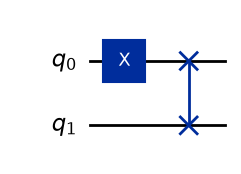

<IPython.core.display.Latex object>

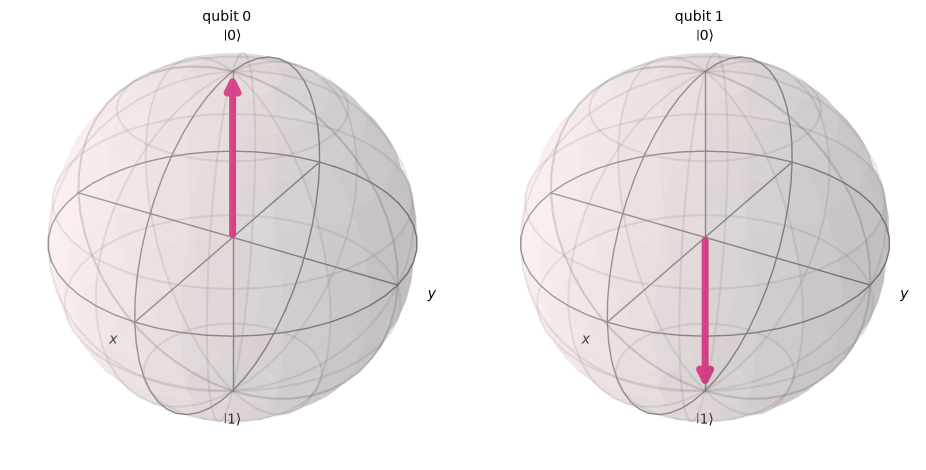

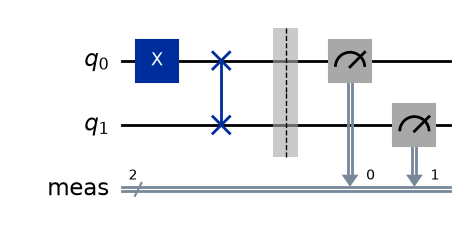

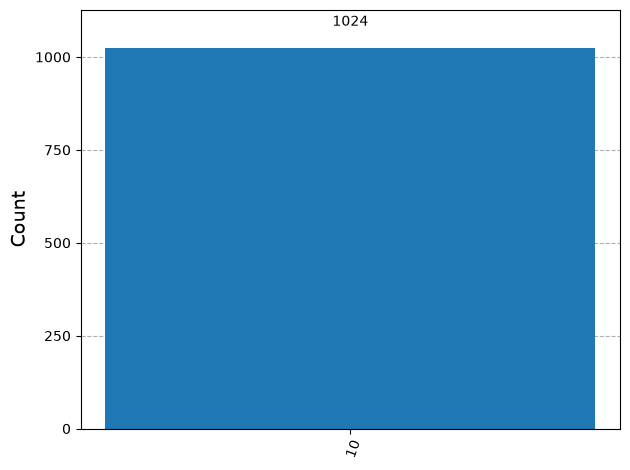

{'10': 1024}


{'10': 1024}

In [14]:
qc = QuantumCircuit(2)
qc.x(0)       # prepare one qubit as 1 and the other as 0
qc.swap(0, 1)
show_state(qc, "SWAP")
measure_counts(qc)


## 14. Toffoli gate — CCX

The Toffoli gate has **two controls and one target**.

The target flips only when both controls are 1:

$$
|a,b,c\rangle\rightarrow
|a,b,c\oplus(a\land b)\rangle.
$$

It is the reversible analogue of an AND-controlled NOT and is important in reversible computation.


Toffoli: both controls are |1>


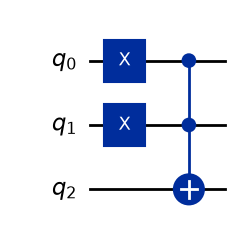

<IPython.core.display.Latex object>

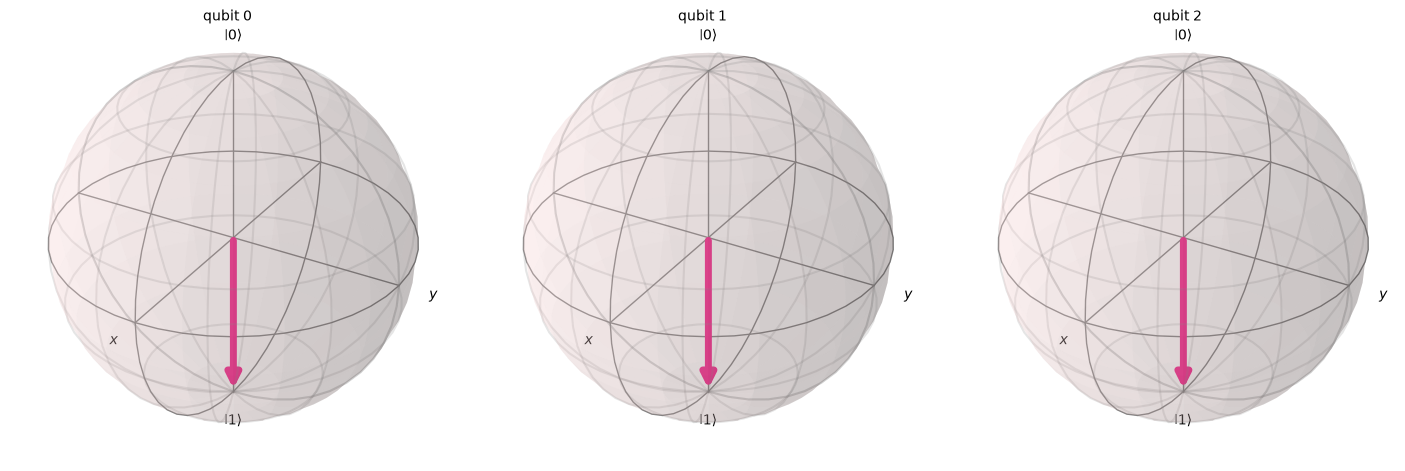

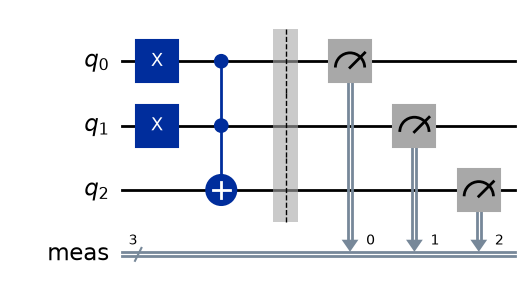

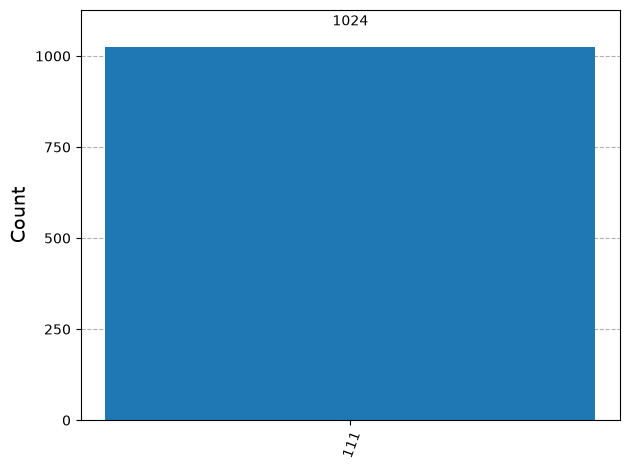

{'111': 1024}


{'111': 1024}

In [15]:
qc = QuantumCircuit(3)
qc.x(0)
qc.x(1)
qc.ccx(0, 1, 2)
show_state(qc, "Toffoli: both controls are |1>")
measure_counts(qc)


## 15. Fredkin gate — CSWAP

Fredkin is a **controlled-SWAP**:
- one control;
- two target qubits;
- the two target states are swapped only when the control is 1.

It preserves the number of 1s in computational-basis states.


Fredkin / controlled-SWAP


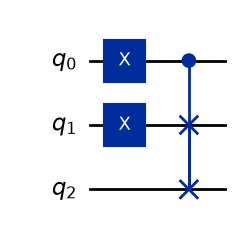

<IPython.core.display.Latex object>

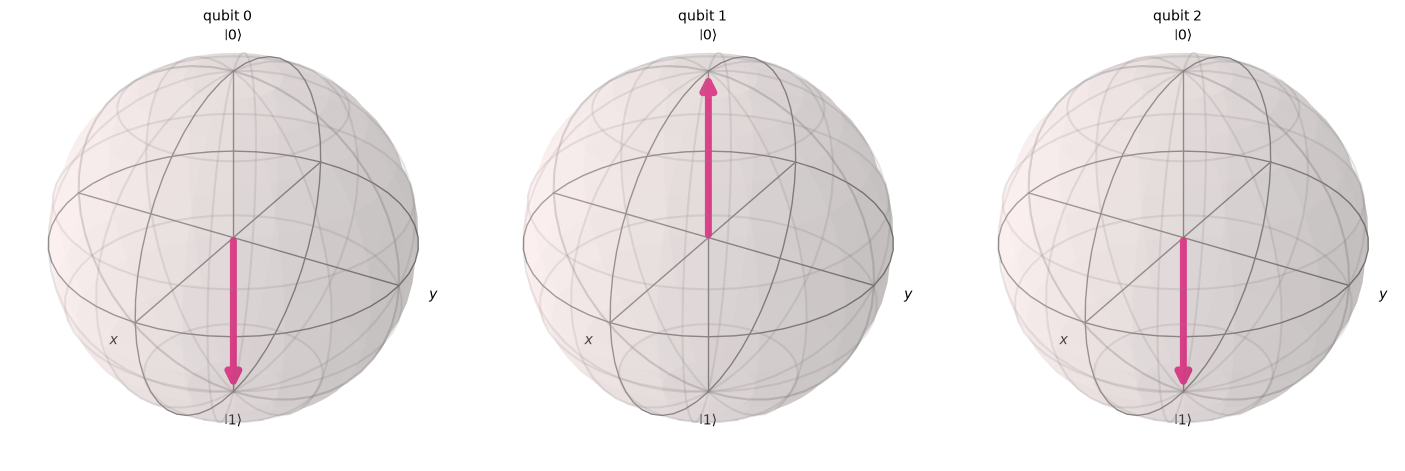

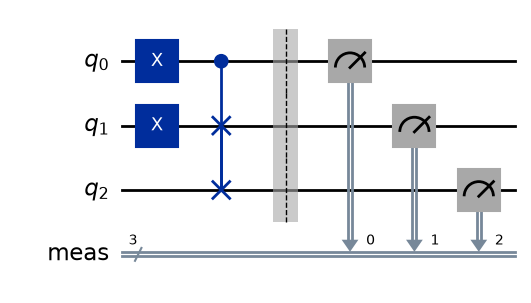

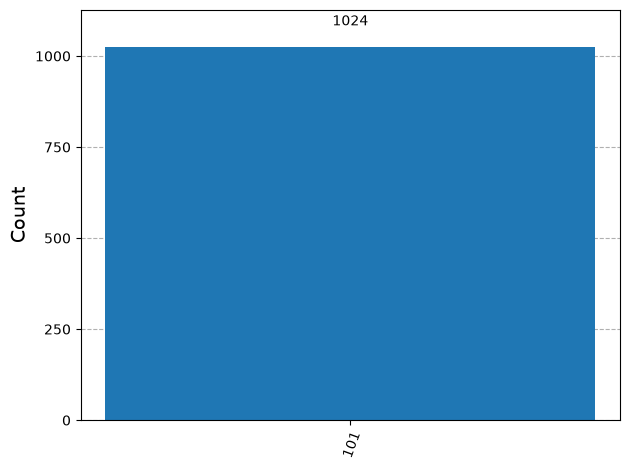

{'101': 1024}


{'101': 1024}

In [16]:
qc = QuantumCircuit(3)
qc.x(0)          # control = 1
qc.x(1)          # target states initially different
qc.cswap(0, 1, 2)
show_state(qc, "Fredkin / controlled-SWAP")
measure_counts(qc)


# Part VII — Bell states and entanglement

## 16. Creating $|\Phi^+\rangle$

Start with

$$
|00\rangle.
$$

Apply H to qubit 0:

$$
|00\rangle
\rightarrow
\frac{|00\rangle+|01\rangle}{\sqrt2}
$$

in Qiskit's little-endian statevector convention.

Then apply CNOT with qubit 0 as control and qubit 1 as target:

$$
|\Phi^+\rangle=
\frac{|00\rangle+|11\rangle}{\sqrt2}.
$$

The two qubits are now entangled: the complete state cannot be factored into two independent single-qubit pure states.


Bell state |Phi+>


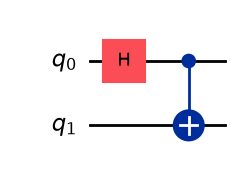

<IPython.core.display.Latex object>

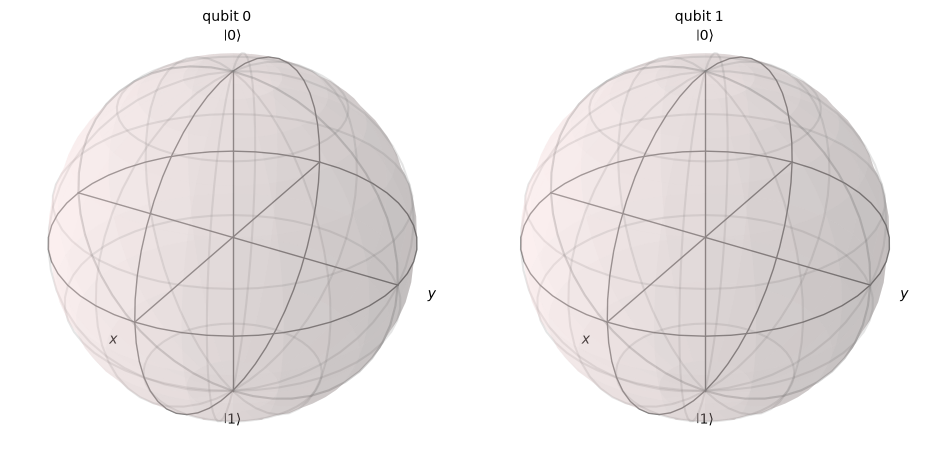

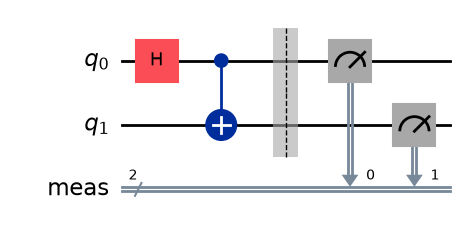

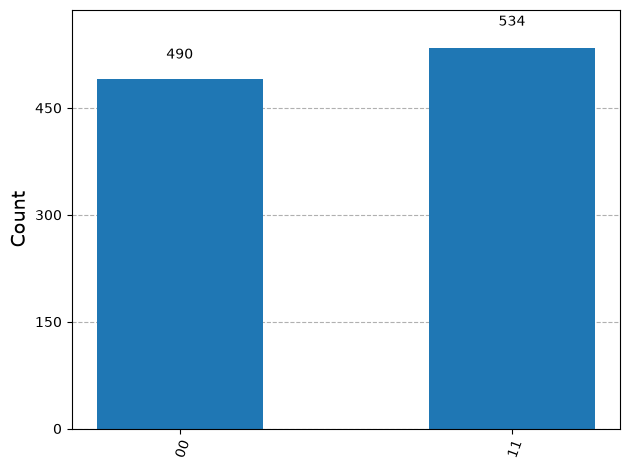

{'00': 490, '11': 534}


{'00': 490, '11': 534}

In [17]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)

state = show_state(bell, "Bell state |Phi+>")
measure_counts(bell)


### Important Bloch-sphere interpretation for Bell states

A Bloch sphere completely represents a **pure state of one qubit**.

For a Bell state, each individual qubit's reduced state is maximally mixed. Therefore its individual Bloch vector is at the **centre** of the sphere.

This does **not** mean that the Bell state has no structure. The information is in the **correlations between the qubits**, which cannot be represented by two independent Bloch arrows.


## 17. All four Bell states

$$
|\Phi^\pm\rangle=\frac{|00\rangle\pm|11\rangle}{\sqrt2}
$$

$$
|\Psi^\pm\rangle=\frac{|01\rangle\pm|10\rangle}{\sqrt2}.
$$



 Phi+


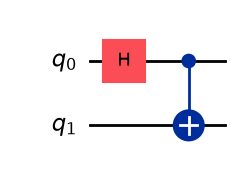

<IPython.core.display.Latex object>

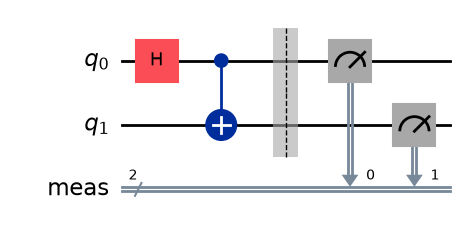

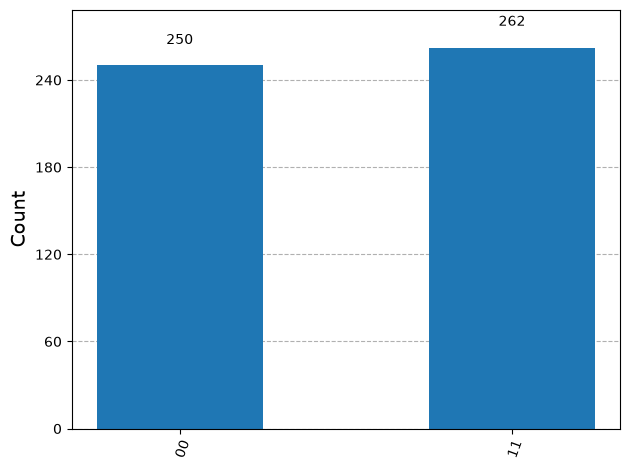

{'11': 262, '00': 250}

 Phi-


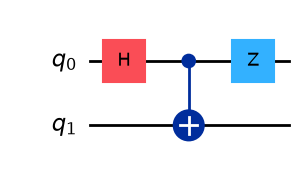

<IPython.core.display.Latex object>

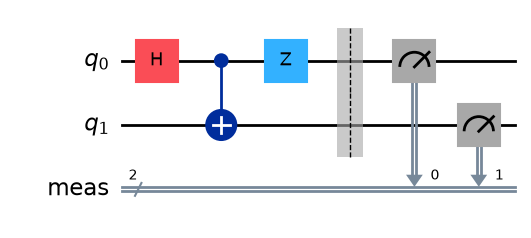

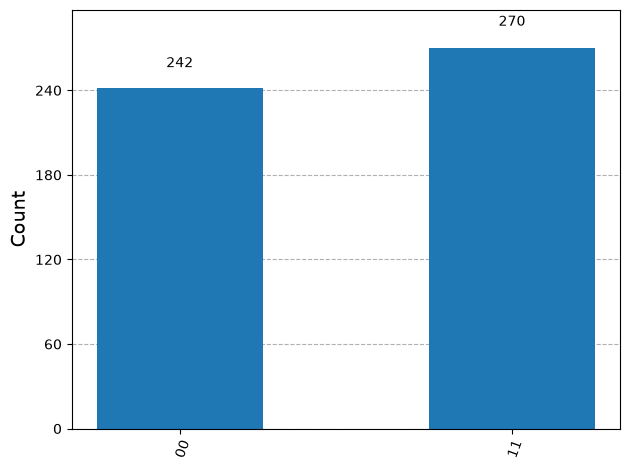

{'11': 270, '00': 242}

 Psi+


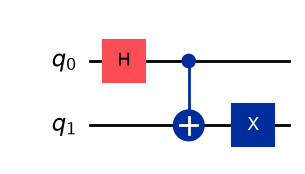

<IPython.core.display.Latex object>

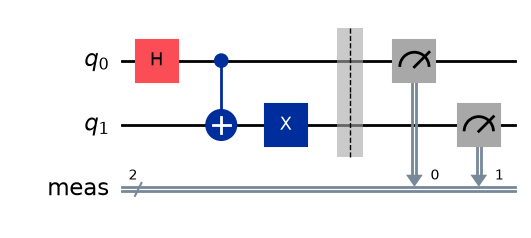

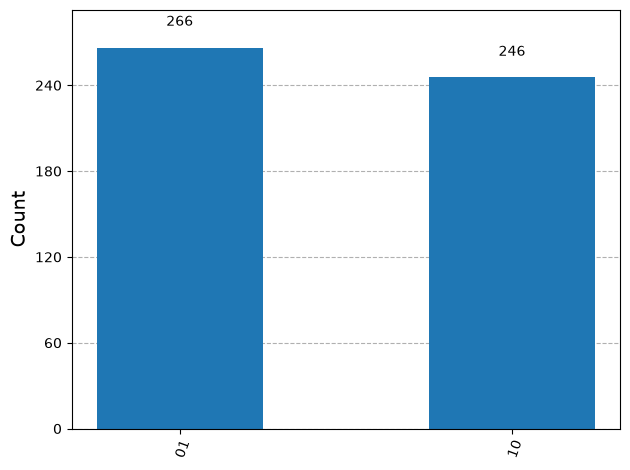

{'01': 266, '10': 246}

 Psi-


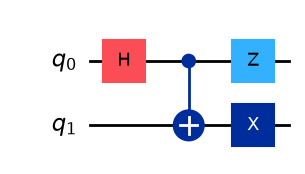

<IPython.core.display.Latex object>

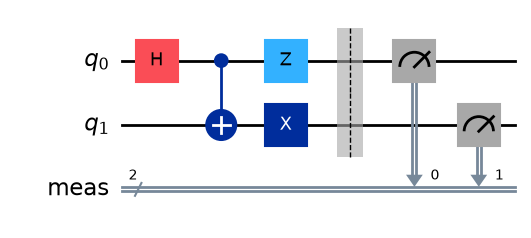

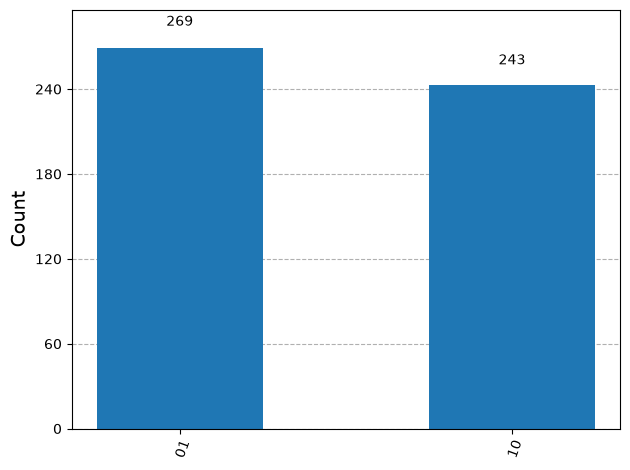

{'01': 269, '10': 243}


In [18]:
def make_bell(label):
    qc = QuantumCircuit(2)
    qc.h(0)
    qc.cx(0, 1)

    if label == "Phi-":
        qc.z(0)
    elif label == "Psi+":
        qc.x(1)
    elif label == "Psi-":
        qc.x(1)
        qc.z(0)
    return qc

for label in ["Phi+", "Phi-", "Psi+", "Psi-"]:
    qc = make_bell(label)
    print("\n", label)
    display(qc.draw("mpl"))
    display(array_to_latex(Statevector.from_instruction(qc).data))
    measure_counts(qc, shots=512)


# Part VIII — Measurement

Quantum measurement in the computational basis projects the state onto $|0\rangle$ or $|1\rangle$.

For

$$
|\psi\rangle=\alpha|0\rangle+\beta|1\rangle,
$$

the probabilities are

$$
P(0)=|\alpha|^2,\qquad P(1)=|\beta|^2.
$$

Measurement is fundamentally different from a unitary gate:
- unitary evolution is reversible;
- projective measurement is not a reversible unitary operation;
- after measurement, the measured state is projected to an outcome compatible with the result.


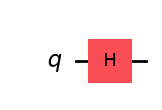

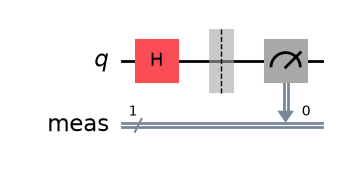

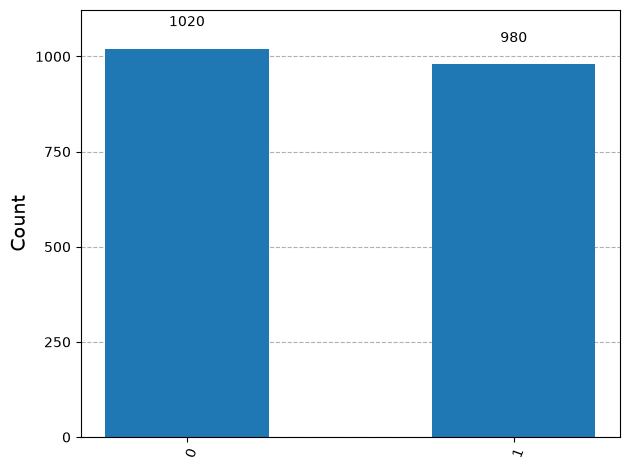

{'1': 980, '0': 1020}


{'1': 980, '0': 1020}

In [19]:
qc = QuantumCircuit(1)
qc.h(0)       # equal superposition
display(qc.draw("mpl"))
measure_counts(qc, shots=2000)


## 18. Measuring in the X basis

Hardware measurement is normally expressed in the computational Z basis.  
To measure in the X basis, rotate the basis first with H.

This allows us to distinguish $|+\rangle$ from $|-\rangle$.


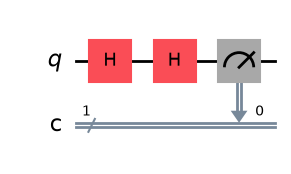

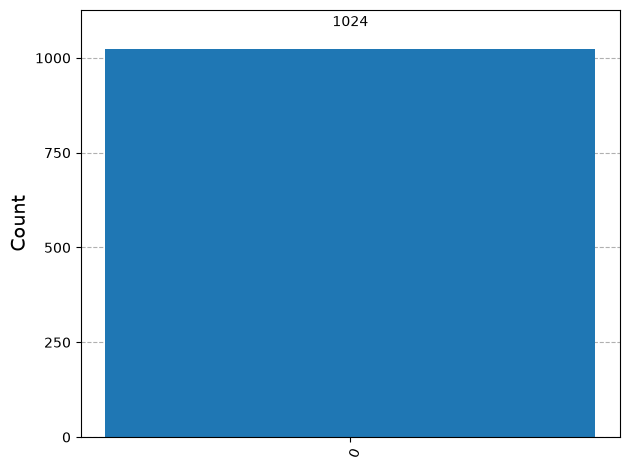

{'0': 1024}


In [20]:
qc = QuantumCircuit(1, 1)
qc.h(0)       # prepare |+>

# X-basis measurement:
qc.h(0)
qc.measure(0, 0)

display(qc.draw("mpl"))
result = simulator.run(transpile(qc, simulator), shots=1024).result()
counts = result.get_counts()
display(plot_histogram(counts))
print(counts)


# Part IX — Circuit visualisation summary


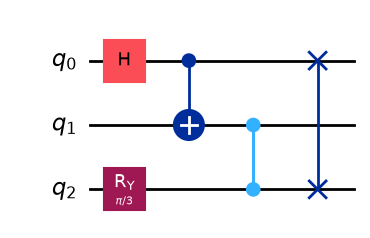

┌───┐              
q_0: ───┤ H ├─────■──────X─
        └───┘   ┌─┴─┐    │ 
q_1: ───────────┤ X ├─■──┼─
     ┌─────────┐└───┘ │  │ 
q_2: ┤ Ry(π/3) ├──────■──X─
     └─────────┘

In [21]:
demo = QuantumCircuit(3)
demo.h(0)
demo.cx(0, 1)
demo.ry(np.pi/3, 2)
demo.cz(1, 2)
demo.swap(0, 2)

display(demo.draw("mpl"))
display(demo.draw("text"))


# Part X — Teaching exercises

### Exercise 1 — Predict before running
For each circuit, predict:
1. the final state;
2. the Bloch-vector direction where appropriate;
3. the measurement probabilities.

Try:
- $X|0\rangle$
- $Y|0\rangle$
- $Z|+\rangle$
- $R_y(\pi/2)|0\rangle$
- $R_z(\pi/2)|+\rangle$

### Exercise 2 — Phase versus probability
Prepare $|+\rangle$, apply Z, and measure directly in the Z basis.  
Why do the probabilities remain approximately 50/50?

Then apply H before measurement. What changes, and why?

### Exercise 3 — Controlled rotation
Set the control first to $|0\rangle$, then to $|1\rangle$. Apply $CR_y(\pi/2)$. Compare the target.

### Exercise 4 — Toffoli truth table
Test all eight computational-basis inputs and verify that the target changes only when both controls are 1.

### Exercise 5 — Bell correlation
Create $|\Phi^+\rangle$ and take 2000 shots. Why should you observe only `00` and `11`, rather than all four two-bit outcomes?

### Exercise 6 — Entanglement question
Why are the individual Bloch vectors of a Bell pair at the centre even though the global two-qubit state is pure?

### Exercise 7 — Build a circuit
Construct a three-qubit circuit containing:
- H
- controlled rotation
- CNOT
- SWAP
- measurement

Draw the circuit and explain every stage in words.


# Gate reference

| Gate | Qubits | Main teaching interpretation |
|---|---:|---|
| X | 1 | Bit flip; $\pi$ rotation about x |
| Y | 1 | Bit + phase change; $\pi$ rotation about y |
| Z | 1 | Phase flip; $\pi$ rotation about z |
| Rx | 1 | Continuous x-axis rotation |
| Ry | 1 | Continuous y-axis rotation |
| Rz | 1 | Continuous z-axis rotation |
| S | 1 | $\pi/2$ phase gate |
| T | 1 | $\pi/4$ phase gate |
| CNOT/CX | 2 | Controlled bit flip |
| CZ | 2 | Controlled phase flip |
| CRx/CRy/CRz | 2 | Controlled continuous rotation |
| CP | 2 | Controlled phase $P(\theta)$ |
| SWAP | 2 | Exchange two qubit states |
| Toffoli/CCX | 3 | Two-controlled NOT |
| Fredkin/CSWAP | 3 | Controlled SWAP |
| Bell circuit | 2 | H + CNOT creates entanglement |
| Measurement | 1+ | Converts quantum outcome probabilities into classical results |

## Final teaching message

A useful progression is:

**state → single-qubit transformation → phase → continuous rotation → control → entanglement → multi-qubit reversible logic → measurement.**

Students should not only memorize gate symbols. They should connect each gate to:
1. its matrix or conditional rule;
2. its effect on amplitudes and phases;
3. its circuit symbol;
4. its Bloch-sphere geometry when a single-qubit description is meaningful;
5. its measurement consequences.
